# 추론 데모

- 단일 이미지 추론 및 시각화
- 배치 추론 (폴더 전체)
- 추론 속도 벤치마크

In [1]:
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from ultralytics import YOLO

print('[OK] 임포트 완료')

[OK] 임포트 완료


### 설정

In [5]:
from pathlib import Path
BASE = Path(r"C:\workspace_python\deeplearning\project")

BEST_WEIGHTS = str(BASE / "runs/detect/pcb_defect_detection/yolov8s_transfer/weights/best.pt")
TEST_IMG_DIR   = Path("./pcb_yolo_dataset/test/images")

CLASSES = [
    "missing_hole", "mouse_bite", "open_circuit",
    "short", "spur", "spurious_copper"
]
COLORS_BGR = [
    (70,  73, 230),
    (157, 123, 69),
    (143, 157, 42),
    (74,  196, 233),
    (97,  162, 244),
    (83,  70,  38),
]
CONF_THRESHOLD = 0.25
IOU_THRESHOLD  = 0.45

# 모델 로드
print(f'[LOAD] 모델 로드: {BEST_WEIGHTS}')
model = YOLO(BEST_WEIGHTS)
print('[OK] 모델 로드 완료')

[LOAD] 모델 로드: C:\workspace_python\deeplearning\project\runs\detect\pcb_defect_detection\yolov8s_transfer\weights\best.pt
[OK] 모델 로드 완료


### 단일 이미지 추론

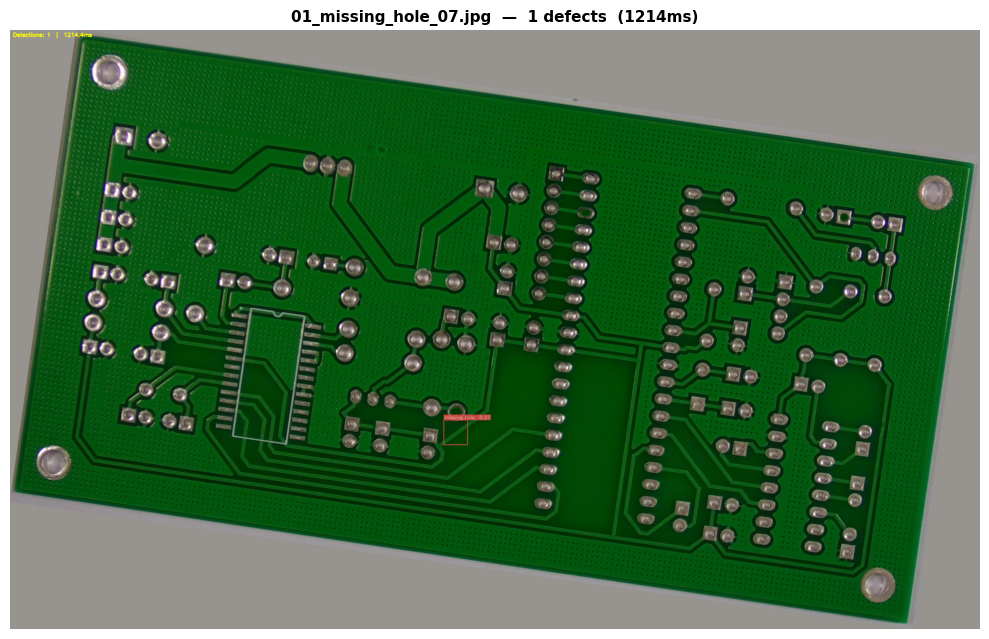


[RESULT] 탐지된 결함 1개:
  ● missing_hole          conf=0.270


In [6]:
def infer_single_image(img_path):
    img_path = Path(img_path)
    if not img_path.exists():
        print(f'[ERROR] 파일 없음: {img_path}')
        return

    t0  = time.time()
    res = model.predict(
        source=str(img_path), conf=CONF_THRESHOLD,
        iou=IOU_THRESHOLD, verbose=False
    )[0]
    elapsed = (time.time() - t0) * 1000

    img     = cv2.imread(str(img_path))
    overlay = img.copy()
    detections = []

    for box in res.boxes:
        xyxy  = box.xyxy[0].cpu().numpy().astype(int)
        cls   = int(box.cls[0])
        conf  = float(box.conf[0])
        color = COLORS_BGR[cls % len(COLORS_BGR)]
        label = f"{CLASSES[cls]}  {conf:.2f}"

        cv2.rectangle(overlay, (xyxy[0],xyxy[1]), (xyxy[2],xyxy[3]), color, 2)
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(overlay, (xyxy[0], xyxy[1]-th-6), (xyxy[0]+tw+4, xyxy[1]), color, -1)
        cv2.putText(overlay, label, (xyxy[0]+2, xyxy[1]-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
        detections.append({"class": CLASSES[cls], "conf": conf, "bbox": xyxy.tolist()})

    result_img = cv2.addWeighted(overlay, 0.85, img, 0.15, 0)
    info = f"Detections: {len(detections)}  |  {elapsed:.1f}ms"
    cv2.putText(result_img, info, (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,255), 2)

    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"{img_path.name}  —  {len(detections)} defects  ({elapsed:.0f}ms)",
              fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig("inference_single.png", dpi=150)
    plt.show()

    print(f'\n[RESULT] 탐지된 결함 {len(detections)}개:')
    for d in detections:
        print(f"  ● {d['class']:<20}  conf={d['conf']:.3f}")

# 테스트 이미지 1장으로 실행
img_list = list(TEST_IMG_DIR.glob("*.jpg")) + list(TEST_IMG_DIR.glob("*.png"))
if img_list:
    infer_single_image(img_list[0])
else:
    print('[WARN] 테스트 이미지가 없습니다.')

### 배치 추론 (폴더 전체)

In [7]:
output_dir = Path("./inference_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

img_list = list(TEST_IMG_DIR.glob("*.jpg")) + list(TEST_IMG_DIR.glob("*.png"))
if not img_list:
    print('[WARN] 테스트 이미지 없음')
else:
    print(f'[BATCH] {len(img_list)}장 추론 시작...')
    summary = []

    for ip in img_list:
        res   = model.predict(str(ip), conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, verbose=False)[0]
        count = len(res.boxes)
        classes_found = [CLASSES[int(b.cls[0])] for b in res.boxes if int(b.cls[0]) < len(CLASSES)]
        summary.append({"file": ip.name, "count": count, "classes": classes_found})
        res.save(filename=str(output_dir / f"{ip.stem}_pred.jpg"))

    total = sum(s["count"] for s in summary)
    print(f'\n[SUMMARY] {len(img_list)}장, 결함 {total}개 탐지')
    print(f'{"파일명":<35} {"탐지수":>5}  클래스')
    print("-" * 65)
    for s in summary[:10]:  # 최대 10개만 출력
        print(f"{s['file']:<35} {s['count']:>5}  {', '.join(s['classes'])}")
    if len(summary) > 10:
        print(f'  ... 외 {len(summary)-10}개')

[BATCH] 70장 추론 시작...

[SUMMARY] 70장, 결함 115개 탐지
파일명                                   탐지수  클래스
-----------------------------------------------------------------
01_missing_hole_07.jpg                  1  missing_hole
01_mouse_bite_13.jpg                    1  open_circuit
01_open_circuit_04.jpg                  0  
01_open_circuit_09.jpg                  0  
01_short_03.jpg                         0  
01_short_07.jpg                         0  
01_spurious_copper_15.jpg               0  
01_spur_03.jpg                          1  spur
01_spur_09.jpg                          0  
04_missing_hole_06.jpg                  1  missing_hole
  ... 외 60개


### 추론 속도 벤치마크

[BENCHMARK] 50장 기준
  평균 추론 시간 : 37.7 ms/image
  최소           : 25.0 ms
  최대           : 51.0 ms
  FPS            : 26.5


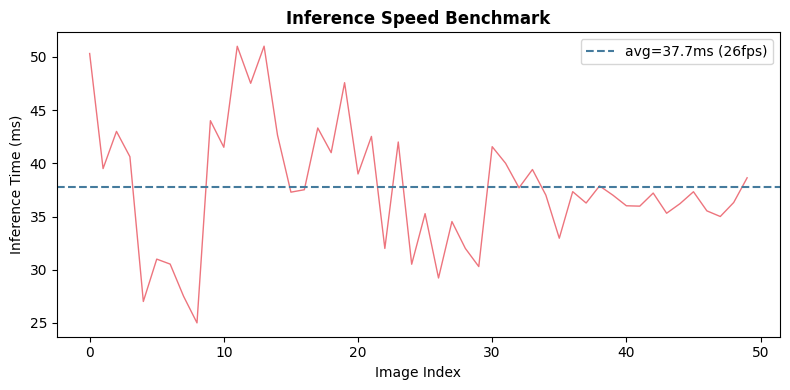

[SAVE] inference_speed.png


In [8]:
img_list = (list(TEST_IMG_DIR.glob("*.jpg")) + list(TEST_IMG_DIR.glob("*.png")))[:50]
if not img_list:
    print('[WARN] 테스트 이미지 없음')
else:
    times = []
    for ip in img_list:
        t0 = time.time()
        model.predict(str(ip), conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, verbose=False)
        times.append((time.time() - t0) * 1000)

    avg = np.mean(times)
    fps = 1000 / avg

    print(f'[BENCHMARK] {len(times)}장 기준')
    print(f'  평균 추론 시간 : {avg:.1f} ms/image')
    print(f'  최소           : {min(times):.1f} ms')
    print(f'  최대           : {max(times):.1f} ms')
    print(f'  FPS            : {fps:.1f}')

    plt.figure(figsize=(8, 4))
    plt.plot(times, color="#E63946", linewidth=1, alpha=0.7)
    plt.axhline(y=avg, color="#457B9D", linestyle="--",
                label=f"avg={avg:.1f}ms ({fps:.0f}fps)")
    plt.xlabel("Image Index")
    plt.ylabel("Inference Time (ms)")
    plt.title("Inference Speed Benchmark", fontsize=12, fontweight="bold")
    plt.legend()
    plt.tight_layout()
    plt.savefig("inference_speed.png", dpi=150)
    plt.show()
    print('[SAVE] inference_speed.png')